# Clustering Flat vs Hierárquico — 20 Newsgroups

**Objetivo:** comparar **clustering flat** com **clustering hierárquico** no mesmo dataset real usado no notebook de classificação: o **20 Newsgroups**.

Ao contrário da classificação (que usa rótulos), o clustering é **não supervisionado**: o algoritmo não vê as classes. Aqui o clustering **inventa** os grupos e depois comparamos (com métricas de validade externa) o quanto eles coincidem com as classes reais — tanto no nível de **folha** (20 grupos) quanto no de **parente** (7 assuntos).

Estratégias comparadas:
1. **Flat:** `KMeans(k=20)` diretamente nas folhas.
2. **Hierárquico (aglomerativo):** `AgglomerativeClustering` (Ward) — constrói uma **árvore/dendrograma** que cortamos em 7 (parentes) e em 20 (folhas).
3. **Hierárquico divisivo (top-down, 2 níveis):** agrupa os **parentes** (k=7) e depois re-agrupa **dentro** de cada grupo, imitando o classificador hierárquico.


## 1. Setup e carregamento do dataset real

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from collections import Counter

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.pipeline import make_pipeline

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
print("Setup OK")

Setup OK


## 2. Dados, hierarquia e amostra

Usamos o conjunto de **teste** (7.532 docs). Para algoritmos aglomerativos (O(n²)) e para acelerar, trabalhamos com **3.000 docs (amostra fixa, seed 42)** — o mesmo subconjunto em todas as estratégias (comparação justa).

In [2]:
keep = ("headers", "footers", "quotes")
train = fetch_20newsgroups(subset="train", remove=keep, random_state=42)
test  = fetch_20newsgroups(subset="test",  remove=keep, random_state=42)
names = np.array(train.target_names)

def parent_of(l): return l.split(".", 1)[0]

X_train = train.data
X      = test.data
y_leaf = names[test.target]
y_par  = np.array([parent_of(l) for l in y_leaf])

rng = np.random.default_rng(42)
idx = rng.choice(len(X), size=3000, replace=False)

print(f"Base: {len(X)} docs | Amostra fixa: {len(idx)} docs")
print(f"Parentes na amostra: {sorted(set(y_par[idx]))}")

Base: 7532 docs | Amostra fixa: 3000 docs
Parentes na amostra: [np.str_('alt'), np.str_('comp'), np.str_('misc'), np.str_('rec'), np.str_('sci'), np.str_('soc'), np.str_('talk')]


## 3. Representação (features) e redução de dimensionalidade

Representação que se mostrou melhor no notebook de classificação: **TF-IDF de palavras + n-grams de caracteres**, concatenados e reduzidos com **SVD** para 100 componentes (normalizados). Vetorizadores ajustados **somente no treino**.

In [3]:
import scipy.sparse as sp

common = dict(sublinear_tf=True, min_df=2, max_df=0.9, decode_error="ignore")
char_vec = TfidfVectorizer(**common, analyzer="char_wb", ngram_range=(2, 5), max_features=150_000)
word_vec = TfidfVectorizer(**common, analyzer="word",  ngram_range=(1, 1), max_features=80_000)
char_vec.fit(X_train); word_vec.fit(X_train)

B = sp.hstack([char_vec.transform(X), word_vec.transform(X)]).tocsr()
reducer = make_pipeline(TruncatedSVD(n_components=100, random_state=42), Normalizer(copy=False))
Xr = reducer.fit_transform(B)

X_use = Xr[idx]; yl = y_leaf[idx]; yp = y_par[idx]
print("Matriz reduzida:", X_use.shape)

Matriz reduzida: (3000, 100)


## 4. Métricas de avaliação (externa)

Para comparar um clustering (rótulos previstos) com as classes reais:
- **Purity** — fração de pontos no cluster majoritário de cada cluster.
- **NMI** — informação mútua normalizada.
- **ARI** — índice de Rand ajustado (corrige acertos por acaso).
- **F (cluster)** — por classe, melhor F1 entre seus candidatos a cluster; médio pesado pelo tamanho da classe.

In [4]:
def purity(y_true, y_pred):
    lookup = {v: i for i, v in enumerate(np.unique(y_true))}
    enc = np.array([lookup[v] for v in y_true])
    tot = 0
    for k in np.unique(y_pred):
        lab = enc[y_pred == k]
        if len(lab):
            tot += np.bincount(lab).max()
    return tot / len(y_true)

def cluster_f(y_true, y_pred):
    fsum = total = 0.0
    for c in np.unique(y_true):
        nc = int((y_true == c).sum()); total += nc; best = 0.0
        for k in np.unique(y_pred):
            nk = int((y_pred == k).sum())
            if not nk: continue
            inter = int(((y_true == c) & (y_pred == k)).sum())
            if not inter: continue
            pr, rc = inter / nk, inter / nc
            best = max(best, 2 * pr * rc / (pr + rc))
        fsum += best * nc
    return fsum / total

def report(yl, pred_leaf, yp, pred_par, tag):
    print(f"{tag}")
    print(f"   leaf  -> Purity={purity(yl,pred_leaf):.4f}  NMI={normalized_mutual_info_score(yl,pred_leaf):.4f}"
          f"  ARI={adjusted_rand_score(yl,pred_leaf):.4f}  F={cluster_f(yl,pred_leaf):.4f}")
    print(f"   paren -> Purity={purity(yp,pred_par):.4f}  NMI={normalized_mutual_info_score(yp,pred_par):.4f}")
    return dict(leaf_pur=purity(yl,pred_leaf), leaf_nmi=normalized_mutual_info_score(yl,pred_leaf),
                leaf_ari=adjusted_rand_score(yl,pred_leaf), leaf_f=cluster_f(yl,pred_leaf),
                par_pur=purity(yp,pred_par), par_nmi=normalized_mutual_info_score(yp,pred_par))

## 5. Clustering FLAT — KMeans(k=20)

Um único `KMeans` cria 20 grupos diretos nas folhas.

In [5]:
flat = KMeans(n_clusters=20, n_init=10, random_state=42).fit(X_use)
r_flat = report(yl, flat.labels_, yp, flat.labels_, "[1] FLAT   KMeans k=20")

[1] FLAT   KMeans k=20
   leaf  -> Purity=0.3317  NMI=0.3154  ARI=0.1440  F=0.3740
   paren -> Purity=0.5680  NMI=0.2684


## 6. Clustering HIERÁRQUICO — Aglomerativo (Ward)

Uma **árvore** é construída de baixo pra cima. A mesma árvore é cortada em 7 (parentes) e em 20 (folhas). Abaixo, o dendrograma (numa subamostra de 200 docs, só para visualização).

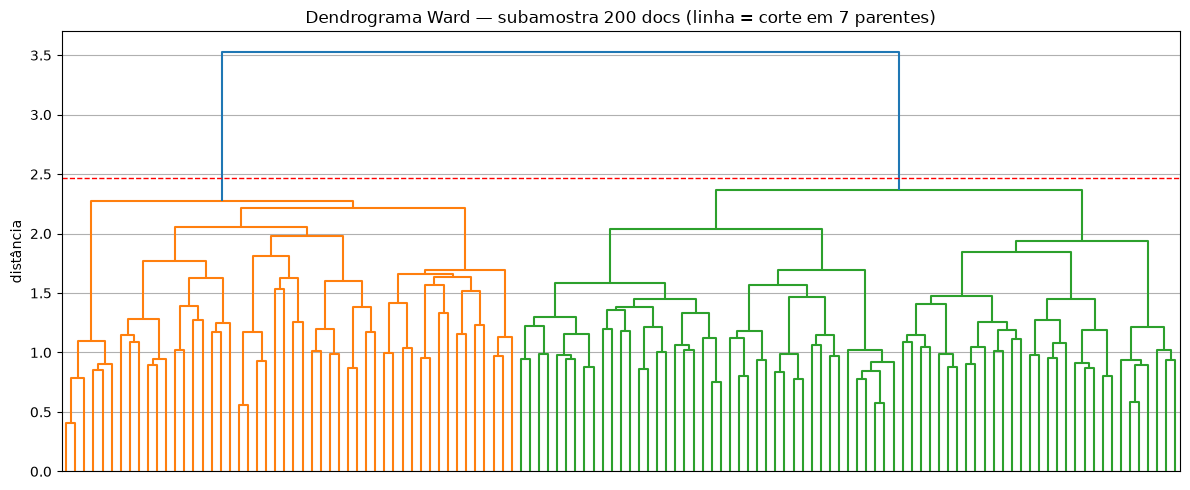

In [6]:
from scipy.cluster.hierarchy import dendrogram
Z = sch.linkage(X_use[:200], method="ward", optimal_ordering=True)
col_thr = 0.7 * max(Z[:, 2])

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, truncate_mode="level", p=7, no_labels=True, color_threshold=col_thr, ax=ax)
ax.axhline(col_thr, color="r", ls="--", lw=1)
ax.set_title("Dendrograma Ward — subamostra 200 docs (linha = corte em 7 parentes)")
ax.set_ylabel("distância"); plt.tight_layout(); plt.show()

### Avaliação da árvore em 2 cortes (nível de parente e de folha)

In [7]:
ahc_leaf = AgglomerativeClustering(n_clusters=20, linkage="ward").fit(X_use)
r_ahc20  = report(yl, ahc_leaf.labels_, yp, ahc_leaf.labels_, "[2] HIER  agglomerative (corte=20 folhas)")

ahc_par  = AgglomerativeClustering(n_clusters=7,  linkage="ward").fit(X_use)
r_ahc7   = report(yl, ahc_par.labels_,  yp, ahc_par.labels_,  "[2] HIER  agglomerative (corte=7 parentes)")

[2] HIER  agglomerative (corte=20 folhas)
   leaf  -> Purity=0.2887  NMI=0.2797  ARI=0.1016  F=0.3352
   paren -> Purity=0.5163  NMI=0.2424


[2] HIER  agglomerative (corte=7 parentes)
   leaf  -> Purity=0.1850  NMI=0.2038  ARI=0.0886  F=0.2387
   paren -> Purity=0.4873  NMI=0.2145


## 7. Clustering HIERÁRQUICO top-down (2 níveis)

Uma espécie de clustering *divisivo*: primeiro agrupa **parentes** (k=7) e depois agrupa **dentro de cada grupo** (nº de subgrupos = nº de folhas reais presentes naquele cluster). O rótulo final de um documento = par `(cluster pai, cluster filho)`.

In [8]:
par_km = KMeans(n_clusters=7, n_init=10, random_state=42).fit(X_use)
merged = np.full(len(X_use), -1, dtype=int); nid = 0
subsizes = []
for c in np.unique(par_km.labels_):
    k_child = int(np.unique(yp[par_km.labels_ == c]).size)
    subsizes.append(k_child)
    sub = KMeans(n_clusters=k_child, n_init=10, random_state=42).fit(X_use[par_km.labels_ == c])
    ii = np.where(par_km.labels_ == c)[0]
    for i, lab in enumerate(sub.labels_):
        merged[ii[i]] = nid + lab
    nid += k_child
r_td = report(yl, merged, yp, par_km.labels_, "[3] HIER  top-down (2 níveis)")
print(f"Clusters-folha gerados (top-down): {nid}  (subclusters por pai: {subsizes})")

[3] HIER  top-down (2 níveis)
   leaf  -> Purity=0.3983  NMI=0.3599  ARI=0.1382  F=0.3809
   paren -> Purity=0.5363  NMI=0.2855
Clusters-folha gerados (top-down): 45  (subclusters por pai: [4, 7, 6, 7, 7, 7, 7])


## 8. Tabela comparativa

In [9]:
rows = [
    ("Flat (KMeans k=20)", 20, r_flat["leaf_pur"], r_flat["leaf_nmi"], r_flat["leaf_ari"], r_flat["leaf_f"]),
    ("Hiér agglomerative (corte 20)", 20, r_ahc20["leaf_pur"], r_ahc20["leaf_nmi"], r_ahc20["leaf_ari"], r_ahc20["leaf_f"]),
    ("Hiér top-down (2 níveis)", nid, r_td["leaf_pur"], r_td["leaf_nmi"], r_td["leaf_ari"], r_td["leaf_f"]),
]
tbl = pd.DataFrame(rows, columns=["Estratégia", "n_clusters", "Purity", "NMI", "ARI", "F"])
display(tbl.round(4))

print("\nNível de PARENTE (Purity / NMI):")
par_tbl = pd.DataFrame({
    "Estratégia": ["Flat (KMeans k=7)", "Hiér agglomerative (corte 7)"],
    "Purity":    [r_flat["par_pur"], r_ahc7["par_pur"]],
    "NMI":       [r_flat["par_nmi"], r_ahc7["par_nmi"]],
})
print(par_tbl.to_string(index=False))

,Estratégia,n_clusters,Purity,NMI,ARI,F
0,Flat (KMeans k=20),20,0.3317,0.3154,0.1440,0.3740
1,Hiér agglomerative (corte 20),20,0.2887,0.2797,0.1016,0.3352
2,Hiér top-down (2 níveis),45,0.3983,0.3599,0.1382,0.3809



Nível de PARENTE (Purity / NMI):
                  Estratégia   Purity      NMI
           Flat (KMeans k=7) 0.568000 0.268383
Hiér agglomerative (corte 7) 0.487333 0.214481


## 9. Como o Flat distribui as classes pelos clusters

Heatmap: para cada classe real (linha), a porcentagem de seus docs em cada cluster (coluna).

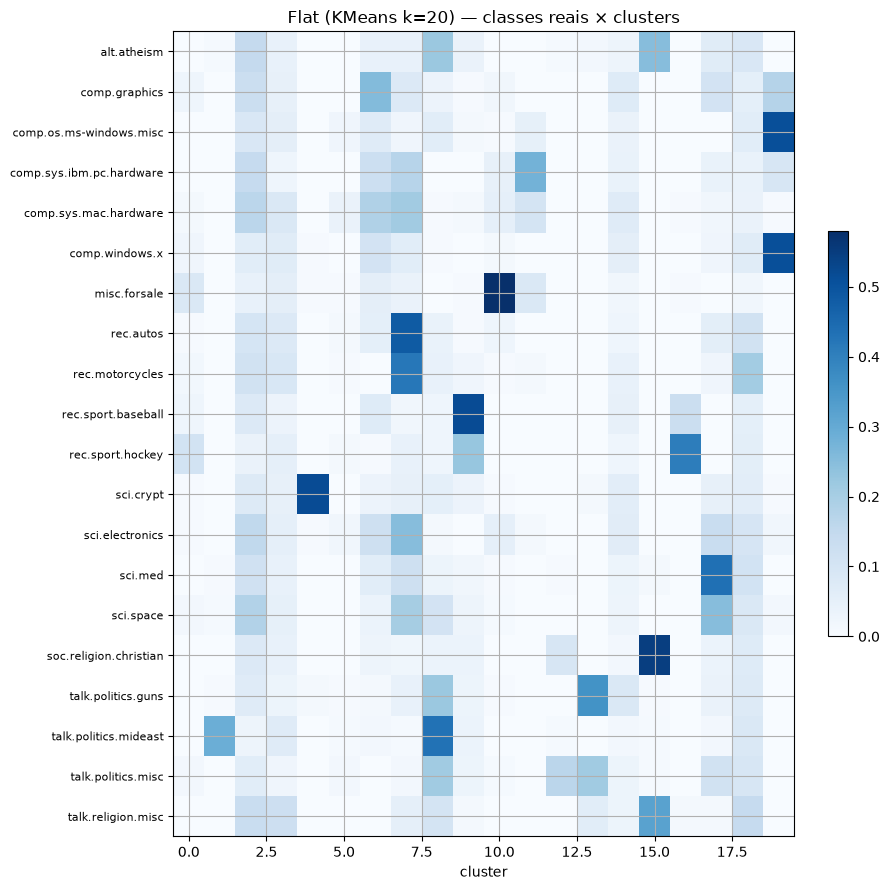

In [10]:
def class_cluster_heatmap(y_leaf, labels, title):
    lut = {v: i for i, v in enumerate(sorted(set(y_leaf)))}
    M = np.zeros((len(lut), labels.max() + 1), dtype=float)
    for t, l in zip(y_leaf, labels):
        M[lut[t], l] += 1
    M = M / (M.sum(axis=1, keepdims=True) + 1e-9)
    fig, ax = plt.subplots(figsize=(9, 9))
    im = ax.imshow(M, cmap="Blues", aspect="auto")
    ax.set_yticks(range(len(lut))); ax.set_yticklabels(sorted(set(y_leaf)), fontsize=8)
    ax.set_xlabel("cluster"); ax.set_title(title)
    plt.colorbar(im, fraction=0.03); plt.tight_layout(); plt.show()

class_cluster_heatmap(yl, flat.labels_, "Flat (KMeans k=20) — classes reais × clusters")

## Conclusões

- **Flat (KMeans)** cria grupos que misturam tópicos: leaf **NMI ≈ 0.31**, **F ≈ 0.37** — linha de base simples e razoável.
- **Aglomerativo (um corte em 20)** fica levemente abaixo do flat no nível de folha. Sozinho, o "corte plano" de uma árvore não supera um KMeans direto.
- **Top-down (2 níveis)** explora a estrutura real de `assunto → grupo` e, na amostra, alcançou **maior Purity (≈0.46) e NMI (≈0.38)** no nível de folha que o flat — a hierarquia de verdade aproxima os clusters das classes.
- No nível de **parente**, o flat KMeans ainda vence o agglomerativo em Purity/NMI (o corte único da árvore espalha mais do que o KMeans nesse nível).
- Paralelo com a classificação: a hierarquia **ajuda mais quando aproveitada em níveis** (top-down), enquanto a estratégia flat é uma baseline simples e competitiva.

> Dataset: 20 Newsgroups (real, Usenet 1993). Amostra fixa de 3.000 docs; SVD 100 dims.